<hr style='border-top:4px solid #1F77B4;'>

<h2><span style="color: #1F77B4; font-size: 35px">Chapitre 3</span></h2>
<h1><span style="color: #1F77B4; font-size: 50px">Réduction de la dimension</span></h1>

Ce carnet reprend, dans l'ordre du chapitre, l'ensemble des extraits de code présentés dans le texte : ACP et ADL pour les méthodes linéaires, puis MDS et t-SNE pour les méthodes non linéaires, à partir des jeux de données <i>Breast Cancer Wisconsin</i>, <i>Wine</i> et <i>Digits</i>. Les cellules doivent être exécutées séquentiellement, car certaines réutilisent des variables ou des résultats définis en amont.

**Bibliothèques requises** : `numpy`, `pandas`, `matplotlib`, `scikit-learn` (≥ 1.8) et `kneed` (≥ 0.8.6).  
**Installation complémentaire** : `kneed` s'installe avec `pip install kneed`.  
**Données externes** : aucun fichier externe n'est nécessaire.  
**Exécution** : les versions utilisées sont affichées par la cellule de configuration ; certaines cellules consacrées à MDS et à t-SNE peuvent demander plusieurs minutes.

<hr style='border-top:4px solid #1F77B4;'>

In [1]:
# Configuration générale : bibliothèques, versions et affichage
import sys
from importlib.metadata import version as package_version

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PAQUETS = ('numpy', 'pandas', 'matplotlib', 'scikit-learn', 'kneed')

print(f"{'python':<18} {sys.version.split()[0]}")
for paquet in PAQUETS:
    print(f"{paquet:<18} {package_version(paquet)}")

plt.rcParams.update({
    'mathtext.fontset': 'cm',
    'text.usetex': False,
})

# Couleurs du livre (palette viridis)
VIOLET, SARCELLE, VERT = '#482878', '#21918c', '#5ec962'
BLEU    = '#3b528b'    # nuages de données / éléments neutres
MAGENTA = '#bf00bf'    # courbes de modèle
BORD = {VIOLET: '#2e1a4d', SARCELLE: '#14615d', VERT: '#3a7d3f', BLEU: '#2c3e6b'}
ZONE = {VIOLET: '#d5cbe4', SARCELLE: '#c4e3e1', VERT: '#def2e0'}

python             3.12.13
numpy              2.5.1
pandas             3.0.3
matplotlib         3.11.0
scikit-learn       1.9.0
kneed              0.8.6


In [2]:
# Fonction utilitaire de sauvegarde des figures (PDF)
import os

def save_figure(fig, path):
    directory = os.path.dirname(path)
    if directory:
        os.makedirs(directory, exist_ok=True)
    fig.savefig(f"{path}.pdf", format="pdf", bbox_inches='tight')

<hr style='border-top:4px solid #1F77B4;'>

<h3><span style="font-size: 30px">&#127924;</span> Figure : Impact du choix de l'axe de projection (ACP)</h3>

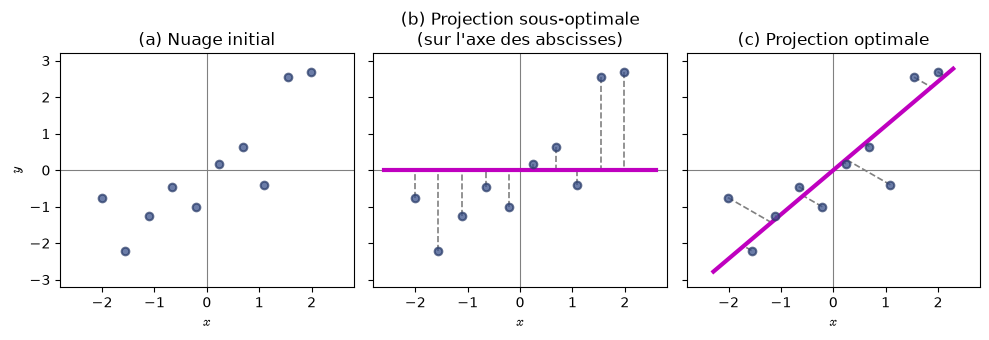

In [3]:
import numpy as np

# Nuage de dix points corrélés (coordonnées fixées pour la reproductibilité)
X_pts = np.array([[-2.00, -0.75], [-1.55, -2.20], [-1.10, -1.25],
                  [-0.65, -0.45], [-0.20, -1.00], [ 0.25,  0.18],
                  [ 0.70,  0.65], [ 1.10, -0.40], [ 1.55,  2.55],
                  [ 2.00,  2.70]])
X_c = X_pts - X_pts.mean(axis=0)   # centrage

# Direction de variance maximale (premier vecteur propre de la covariance)
V = (X_c.T @ X_c) / len(X_c)
valeurs_propres, vecteurs_propres = np.linalg.eigh(V)
u1 = vecteurs_propres[:, np.argmax(valeurs_propres)]

# Projections sur l'axe des abscisses (b) et sur la direction u1 (c)
P_x  = np.column_stack([X_c[:, 0], np.zeros(len(X_c))])
P_u1 = np.outer(X_c @ u1, u1)

couleur_nuage, bord_nuage, couleur_axe = '#3b528b', '#2c3e6b', '#bf00bf'

fig, axes = plt.subplots(1, 3, figsize=(10, 3.5), sharey=True)
for ax in axes:
    ax.axhline(0, color='gray', lw=0.8)
    ax.axvline(0, color='gray', lw=0.8)
    ax.scatter(X_c[:, 0], X_c[:, 1], s=30, color=couleur_nuage,
               edgecolors=bord_nuage, linewidths=1.5, alpha=0.75, zorder=3)
    ax.set_xlabel('$x$')
    ax.set_xlim(-2.8, 2.8); ax.set_ylim(-3.2, 3.2)
axes[0].set_ylabel('$y$')
axes[0].set_title("(a) Nuage initial")

# (b) Projection sous-optimale : axe des abscisses
axes[1].plot([-2.6, 2.6], [0, 0], color=couleur_axe, lw=3, zorder=2)
for pt, pr in zip(X_c, P_x):
    axes[1].plot([pt[0], pr[0]], [pt[1], pr[1]], ls='--', lw=1.2,
                 color='gray', zorder=1)
axes[1].set_title("(b) Projection sous-optimale\n(sur l'axe des abscisses)")

# (c) Projection optimale : direction de variance maximale
droite = np.outer([-3.6, 3.6], u1)
axes[2].plot(droite[:, 0], droite[:, 1], color=couleur_axe, lw=3, zorder=2)
for pt, pr in zip(X_c, P_u1):
    axes[2].plot([pt[0], pr[0]], [pt[1], pr[1]], ls='--', lw=1.2,
                 color='gray', zorder=1)
axes[2].set_title("(c) Projection optimale")

plt.tight_layout()
plt.show()

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap3-PCAVectors")

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 3.1 : Lecture des données Breast Cancer Wisconsin</h3>

In [4]:
import numpy as np
from sklearn.datasets import load_breast_cancer
# Chargement du dataset
data = load_breast_cancer()
# Matrice des variables explicatives 'X' et vecteur cible 'y'
X = data.data
y = data.target
# Noms des variables et des classes
feature_names = data.feature_names
target_names = data.target_names

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 3.2 : Standardisation des données (centrage et réduction)</h3>

In [5]:
from sklearn.preprocessing import StandardScaler
# Standardisation des données (centrage et réduction : moyenne 0, écart-type 1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 3.3 : Analyse ACP des données standardisées</h3>

In [6]:
from sklearn.decomposition import PCA

# Instanciation d'un objet PCA 
# Par défaut, toutes les composantes sont calculées
pca_full = PCA()
pca_full.fit(X_scaled)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",None
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized S

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 3.4 : Sorties de l’ACP : vecteurs propres, valeurs propres et scores</h3>

In [7]:
# Vecteurs propres (directions principales / axes)
U_T = pca_full.components_
U = U_T.T

# Valeurs propres (variances des composantes principales)
lambdas = pca_full.explained_variance_
explained_ratio = pca_full.explained_variance_ratio_

# Scores / coordonnées factorielles (données projetées)
C = pca_full.transform(X_scaled)

# Affichage des dimensions
lignes = [
    ("X",        "Données originales",                 X.shape,        "(m, n)"),
    ("X_scaled", "Données centrées-réduites",           X_scaled.shape, "(m, n)"),
    ("U",        "Vecteurs propres (colonnes = u_k)",   U.shape,        "(n, n)"),
    ("lambdas",  "Valeurs propres",                     lambdas.shape,  "(n,)"),
    ("C",        "Scores / coordonnées factorielles",   C.shape,        "(m, n)"),
]

print("=" * 70)
print("Dimensions")
print("=" * 70)
print(f"{'Objet':<10}\t{'Description':<36}\t{'Dimensions':<12}\t{'Forme'}")
print("-" * 70)
for nom, description, dims, forme in lignes:
    print(f"{nom:<10}\t{description:<36}\t{str(dims):<12}\t{forme}")
print("=" * 70)
print(f"Nombre de composantes calculées : {pca_full.n_components_}")

Dimensions
Objet     	Description                         	Dimensions  	Forme
----------------------------------------------------------------------
X         	Données originales                  	(569, 30)   	(m, n)
X_scaled  	Données centrées-réduites           	(569, 30)   	(m, n)
U         	Vecteurs propres (colonnes = u_k)   	(30, 30)    	(n, n)
lambdas   	Valeurs propres                     	(30,)       	(n,)
C         	Scores / coordonnées factorielles   	(569, 30)   	(m, n)
Nombre de composantes calculées : 30


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 3.5 : Seuil de variance expliquée</h3>

In [8]:
# Calcul de la variance expliquée cumulée
cumulative_ratio = np.cumsum(explained_ratio)

# Critère du seuil de variance expliquée
tau = 0.90
q_variance = np.argmax(cumulative_ratio >= tau) + 1

# Affichage
n_affiche = 10
print("=" * 60)
print("Critère 1 : Seuil de variance")
print("=" * 60)
print(f"{'Composante':<12}\t{'Variance (%)':<14}\t{'Variance cumulée (%)'}")
print("-" * 60)
for i in range(n_affiche):
    marque = "  <-- seuil atteint" if (i + 1) == q_variance else ""
    print(f"PC{i + 1:<10}\t{explained_ratio[i] * 100:<14.2f}\t{cumulative_ratio[i] * 100:.2f}{marque}")
print("=" * 60)
print(f"Nombre de composantes pour atteindre {tau * 100:.0f}% de variance : {q_variance}")

Critère 1 : Seuil de variance
Composante  	Variance (%)  	Variance cumulée (%)
------------------------------------------------------------
PC1         	44.27         	44.27
PC2         	18.97         	63.24
PC3         	9.39          	72.64
PC4         	6.60          	79.24
PC5         	5.50          	84.73
PC6         	4.02          	88.76
PC7         	2.25          	91.01  <-- seuil atteint
PC8         	1.59          	92.60
PC9         	1.39          	93.99
PC10        	1.17          	95.16
Nombre de composantes pour atteindre 90% de variance : 7


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 3.6 : Critère de Kaiser ($\lambda_k > 1$)</h3>

In [9]:
import numpy as np

# Nombre de composantes dont la valeur propre est supérieure à 1
q_kaiser = np.sum(lambdas > 1)

# Affichage
n_affiche = 10
print("=" * 40)
print("Critère 2 : Kaiser (λ > 1)")
print("=" * 40)
print(f"{'Composante':<14}\t{'λₖ'}")
print("-" * 40)
for i in range(n_affiche):
    marque = "  <-- seuil atteint" if (i + 1) == q_kaiser else ""
    print(f"PC{i + 1:<10}\t{lambdas[i]:.4f}{marque}")
print("=" * 40)
print(f"Nombre de composantes à retenir (λ > 1) : {q_kaiser}")

Critère 2 : Kaiser (λ > 1)
Composante    	λₖ
----------------------------------------
PC1         	13.3050
PC2         	5.7014
PC3         	2.8229
PC4         	1.9841
PC5         	1.6516
PC6         	1.2095  <-- seuil atteint
PC7         	0.6764
PC8         	0.4775
PC9         	0.4176
PC10        	0.3513
Nombre de composantes à retenir (λ > 1) : 6


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 3.7 : Diagramme des éboulis</h3>

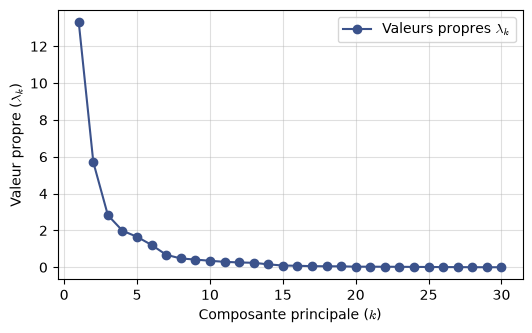

In [10]:
# Diagramme des valeurs propres (Scree plot)
K = len(lambdas)
k = np.arange(1, K + 1)

plt.figure(figsize=(6, 3.5))
plt.plot(k, lambdas, marker="o", color='#3b528b', label="Valeurs propres $\\lambda_k$")
plt.xlabel("Composante principale ($k$)")
plt.ylabel("Valeur propre ($\\lambda_k$)")
plt.legend()
plt.grid(alpha=0.4)
plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 3.8a : Diagramme des éboulis et détection automatique du coude par analyse des différences successives</h3>

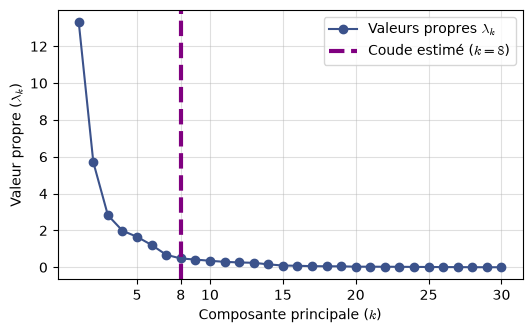

Critère 3 : Coude (heuristique)
Composante  	λₖ          	|Δλ|
------------------------------------------------------------
PC1         	13.3050     	7.6036
PC2         	5.7014      	2.8785
PC3         	2.8229      	0.8388
PC4         	1.9841      	0.3325
PC5         	1.6516      	0.4422
PC6         	1.2095      	0.5331
PC7         	0.6764      	0.1990
PC8         	0.4775      	0.0598  <-- coude estimé
PC9         	0.4176      	0.0663
PC10        	0.3513      	0.0569
Nombre de composantes (coude) : 8


In [11]:
# Détection automatique du coude (heuristique)
# diff[k] = |lambda_{k} - lambda_{k+1}|
diff = np.abs(np.diff(lambdas))
threshold = 0.1
q_elbow = np.argmax(diff < threshold) + 1

# Diagramme des éboulis avec le coude estimé
fig = plt.figure(figsize=(6, 3.5))
plt.plot(k, lambdas, marker="o", color='#3b528b', label="Valeurs propres $\\lambda_k$")
# Ligne verticale indiquant le coude estimé
plt.axvline(x=q_elbow, color="purple", linestyle="--", linewidth=3,
            label=f"Coude estimé ($k = {q_elbow}$)")
plt.xlabel("Composante principale ($k$)")
plt.ylabel("Valeur propre ($\\lambda_k$)")

# Forcer l'affichage de q_elbow sur l'axe des x
ax = plt.gca()
current_ticks = [t for t in ax.get_xticks() if 1 <= t <= K]
ax.set_xticks(sorted(set(current_ticks) | {q_elbow}))

plt.legend()
plt.grid(alpha=0.4)
plt.show()

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap3-PCACoude")

# Affichage
n_affiche = 10
print("=" * 60)
print("Critère 3 : Coude (heuristique)")
print("=" * 60)
print(f"{'Composante':<12}\t{'λₖ':<12}\t{'|Δλ|'}")
print("-" * 60)
for i in range(min(n_affiche, len(diff))):
    marque = "  <-- coude estimé" if (i + 1) == q_elbow else ""
    print(f"PC{i + 1:<10}\t{lambdas[i]:<12.4f}\t{diff[i]:.4f}{marque}")
print("=" * 60)
print(f"Nombre de composantes (coude) : {q_elbow}")

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 3.8b : Diagramme des éboulis et détection automatique du coude par analyse de la courbure (dérivée seconde discrète)</h3>

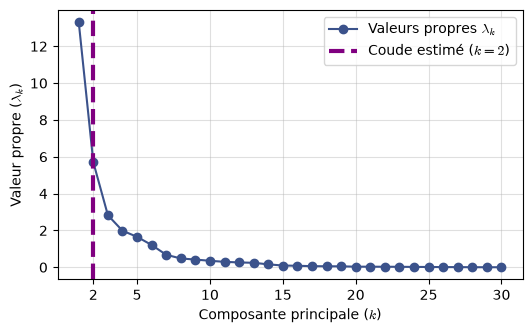

Critère 3 : Coude (dérivée seconde discrète)
Composante  	λₖ          	Δ²λ
------------------------------------------------------------
PC1         	13.3050     	-
PC2         	5.7014      	4.7252  <-- coude estimé
PC3         	2.8229      	2.0397
PC4         	1.9841      	0.5063
PC5         	1.6516      	-0.1097
PC6         	1.2095      	-0.0909
PC7         	0.6764      	0.3341
PC8         	0.4775      	0.1391
PC9         	0.4176      	-0.0065
PC10        	0.3513      	0.0094
PC11        	0.2944      	0.0241
Nombre de composantes (coude) : 2


In [12]:
# Détection automatique du coude (courbure : dérivée seconde discrète)
# d2[k] = lambda_{k-1} - 2*lambda_k + lambda_{k+1}
d2 = lambdas[:-2] - 2 * lambdas[1:-1] + lambdas[2:]
q_elbow_curv = np.argmax(d2) + 2  # +2 :décalage car défini pour k = 2, ..., n-1

# Diagramme des éboulis avec le coude estimé par la courbure
fig = plt.figure(figsize=(6, 3.5))
plt.plot(k, lambdas, marker="o", color='#3b528b', label="Valeurs propres $\\lambda_k$")
# Ligne verticale indiquant le coude estimé
plt.axvline(x=q_elbow_curv, color="purple", linestyle="--", linewidth=3,
            label=f"Coude estimé ($k = {q_elbow_curv}$)")
plt.xlabel("Composante principale ($k$)")
plt.ylabel("Valeur propre ($\\lambda_k$)")
# Forcer l'affichage de q_elbow_curv sur l'axe des x
ax = plt.gca()
current_ticks = [t for t in ax.get_xticks() if 1 <= t <= K]
ax.set_xticks(sorted(set(current_ticks) | {q_elbow_curv}))
plt.legend()
plt.grid(alpha=0.4)
plt.show()

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap3-PCACoude-DeriveeSeconde")

# Affichage
n_affiche = 10
print("=" * 60)
print("Critère 3 : Coude (dérivée seconde discrète)")
print("=" * 60)
print(f"{'Composante':<12}\t{'λₖ':<12}\t{'Δ²λ'}")
print("-" * 60)
print(f"{'PC1':<12}\t{lambdas[0]:<12.4f}\t-")
for i in range(min(n_affiche, len(d2))):
    marque = "  <-- coude estimé" if (i + 2) == q_elbow_curv else ""
    print(f"PC{i + 2:<10}\t{lambdas[i + 1]:<12.4f}\t{d2[i]:.4f}{marque}")
print("=" * 60)
print(f"Nombre de composantes (coude) : {q_elbow_curv}")

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 3.8c : Détection automatique du coude par l'algorithme Kneedle</h3>

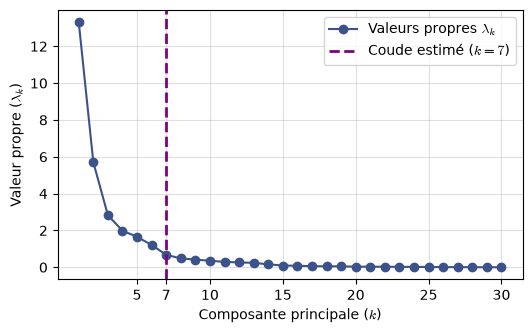

Critère 3 (Kneedle) : Coude
Nombre de composantes (q_elbow) : 7


In [13]:
from kneed import KneeLocator

# Détection automatique du coude via l'algorithme Kneedle (Satopää et al., 2011),
# qui localise le point de courbure maximale.
kl = KneeLocator(k, lambdas, curve='convex', direction='decreasing')
q_elbow_kneedle = kl.knee

# Diagramme des éboulis avec le coude estimé par Kneedle
fig = plt.figure(figsize=(6, 3.5))
plt.plot(k, lambdas, marker="o", color='#3b528b', label="Valeurs propres $\\lambda_k$")
plt.axvline(x=q_elbow_kneedle, color="purple", linestyle="--", linewidth=2,
            label=f"Coude estimé ($k = {q_elbow_kneedle}$)")
plt.xlabel("Composante principale ($k$)")
plt.ylabel("Valeur propre ($\\lambda_k$)")

# Forcer l'affichage de q_elbow sur l'axe des x
ax = plt.gca()
current_ticks = [t for t in ax.get_xticks() if 1 <= t <= K]
ax.set_xticks(sorted(set(current_ticks) | {q_elbow_kneedle}))

plt.legend()
plt.grid(alpha=0.4)
plt.show()

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap3-PCACoude-Kneedle")

print("=" * 60)
print("Critère 3 (Kneedle) : Coude")
print("=" * 60)
print(f"Nombre de composantes (q_elbow) : {q_elbow_kneedle}")
print("=" * 60)

### Résumé

In [14]:
# Synthèse des trois procédés de détection du coude
procedes = [
    (f"Différences successives (seuil = {threshold})", q_elbow),
    ("Dérivée seconde discrète",                       q_elbow_curv),
    ("Algorithme Kneedle",                             q_elbow_kneedle),
]

# Affichage
LARGEUR, COL = 60, 44
print("=" * LARGEUR)
print("Critère 3 : coude du diagramme des éboulis")
print("=" * LARGEUR)
print(f"{'Procédé':<{COL}}{'k*':>4}")
print("-" * LARGEUR)
for nom, q in procedes:
    print(f"{nom:<{COL}}{q:>4}")
print("=" * LARGEUR)

Critère 3 : coude du diagramme des éboulis
Procédé                                       k*
------------------------------------------------------------
Différences successives (seuil = 0.1)          8
Dérivée seconde discrète                       2
Algorithme Kneedle                             7


<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 3.9 : Projection des données sur les deux premières composantes principales et visualisation dans le plan factoriel</h3>

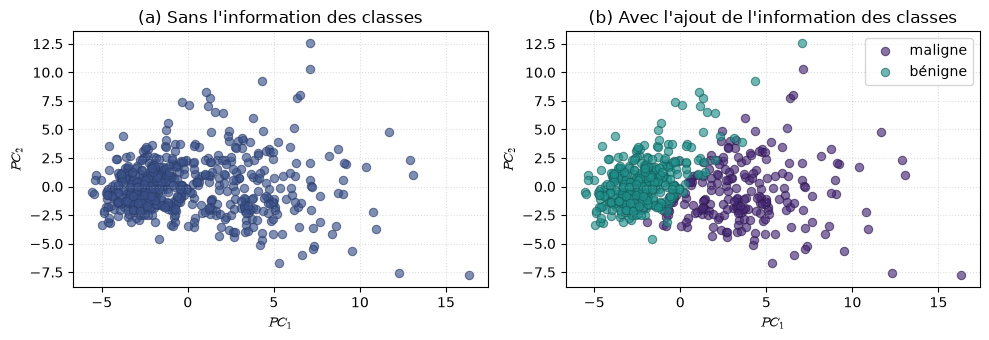

In [15]:
# Projection en 2 dimensions
pca_2 = PCA(n_components=2)
C_2 = pca_2.fit_transform(X_scaled)  # C_2 : (m, 2)

# Deux panneaux : sans, puis avec l'information des classes
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].scatter(C_2[:, 0], C_2[:, 1], color=BLEU,
                edgecolors=BORD[BLEU], linewidths=0.8, alpha=0.65)
axes[0].set_title("(a) Sans l'information des classes")

classes    = np.unique(y)
couleurs   = [VIOLET, SARCELLE]
etiquettes = {0: 'maligne', 1: 'bénigne'}

for cls, couleur in zip(classes, couleurs):
    idx = (y == cls)
    axes[1].scatter(C_2[idx, 0], C_2[idx, 1], color=couleur,
                    edgecolors=BORD[couleur], linewidths=0.8,
                    label=etiquettes[cls], alpha=0.65)

axes[1].set_title("(b) Avec l'ajout de l'information des classes")
axes[1].legend()

for ax in axes:
    ax.set_xlabel('$PC_1$')
    ax.set_ylabel('$PC_2$')
    ax.grid(alpha=0.4, linestyle=':')

plt.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap3-PCAProjection")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 3.10 : Chargement et standardisation du jeu de données Wine</h3>

In [16]:
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler

data = load_wine()
X, y = data.data, data.target

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 3.11 : Application de l'ADL sur le jeu de données Wine et projection dans un espace de dimension deux</h3>

In [17]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Application de l'ADL avec q = 2 composantes discriminantes
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

# Fixe le signe de chaque axe de façon déterministe
signes = np.sign(X_lda[0, :])
X_lda *= signes

print("Dimension originale :", X.shape)
print("Dimension après ADL :", X_lda.shape)

Dimension originale : (178, 13)
Dimension après ADL : (178, 2)


<h3><span style="font-size: 30px">&#127924;</span> Figure : Projection ADL du jeu de données Wine</h3>

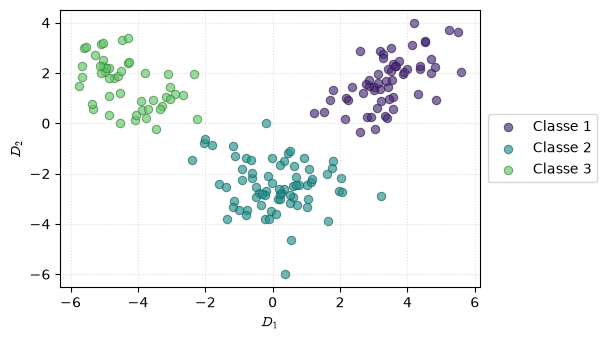

In [18]:
fig, ax = plt.subplots(figsize=(5, 3.5))

classes  = np.unique(y)
couleurs = [VIOLET, SARCELLE, VERT]

for cls in classes:
    idx = (y == cls)
    ax.scatter(X_lda[idx, 0], X_lda[idx, 1], alpha=0.65,
               color=couleurs[cls], edgecolors=BORD[couleurs[cls]],
               linewidths=0.8, label=f"Classe {cls + 1}")

ax.set_xlabel('$D_1$')
ax.set_ylabel('$D_2$')
ax.grid(alpha=0.4, linestyle=':')

plt.tight_layout()

# légende centrée verticalement à droite
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap3-LDA_Projection2D")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 3.12 : Comparaison des projections ACP et ADL sur le jeu de données Wine</h3>

In [19]:
from sklearn.decomposition import PCA

# ACP : projection non supervisée
Z_pca = PCA(n_components=2).fit_transform(X_scaled)

# ADL : projection supervisée (utilise les étiquettes y)
Z_lda = LinearDiscriminantAnalysis(n_components=2).fit_transform(X_scaled, y)

# Fixe le signe de chaque axe de façon déterministe
for Z in (Z_pca, Z_lda):
    signes = np.sign(Z[0, :])
    Z *= signes

<h3><span style="font-size: 30px">&#127924;</span> Figure : Comparaison des projections ACP et ADL (Wine)</h3>

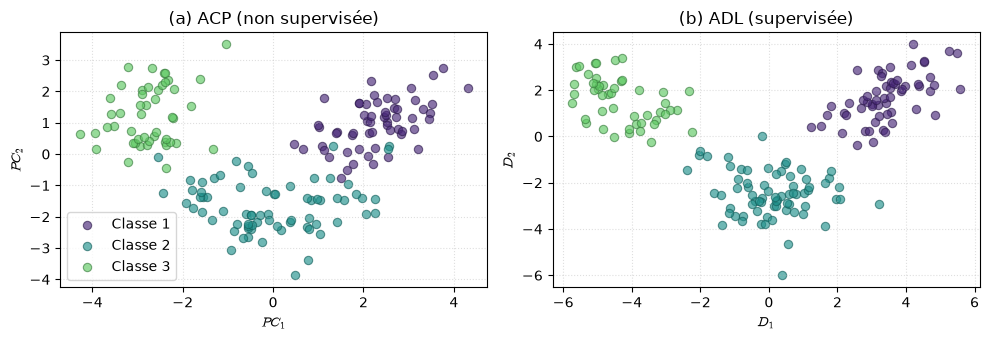

In [20]:
# Affichage côte à côte
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

classes  = np.unique(y)
couleurs = [VIOLET, SARCELLE, VERT]

for ax, Z, titre, xlab, ylab in [
        (axes[0], Z_pca, "(a) ACP (non supervisée)", '$PC_1$', '$PC_2$'),
        (axes[1], Z_lda, "(b) ADL (supervisée)",     '$D_1$',  '$D_2$')]:
    for cls, couleur in zip(classes, couleurs):
        idx = (y == cls)
        ax.scatter(Z[idx, 0], Z[idx, 1], alpha=0.65,
                   color=couleur, edgecolors=BORD[couleur],
                   linewidths=0.8, label=f"Classe {cls + 1}")
    ax.set_title(titre)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    # ax.tick_params(axis='both', labelsize=12)
    ax.grid(alpha=0.4, linestyle=':')

axes[0].legend(loc='lower left')

plt.tight_layout()

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap3-ACPvsADL")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 3.13 : Application du MDS métrique sur le jeu de données Wine</h3>

In [21]:
from sklearn.manifold import MDS

mds = MDS(n_components=2,
          metric_mds=True,
          metric='euclidean',
          random_state=42,
          init='random',
          n_init=10)
Z_mds = mds.fit_transform(X_scaled)

<h3><span style="font-size: 30px">&#127924;</span> Figure : Projection MDS du jeu de données Wine</h3>

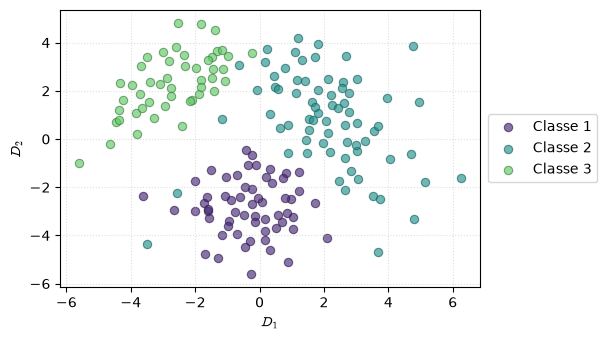

In [22]:
fig, ax = plt.subplots(figsize=(5, 3.5))

classes  = np.unique(y)
couleurs = [VIOLET, SARCELLE, VERT]

for cls, couleur in zip(classes, couleurs):
    idx = (y == cls)
    ax.scatter(Z_mds[idx, 0], Z_mds[idx, 1], alpha=0.65,
               color=couleur, edgecolors=BORD[couleur], linewidths=0.8,
               label=f"Classe {cls + 1}")

ax.set_xlabel('$D_1$')
ax.set_ylabel('$D_2$')
ax.grid(alpha=0.4, linestyle=':')

plt.tight_layout()

# légende centrée verticalement à droite
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0.)

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap3-MDS-Projection")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 3.14 : Comparaison des matrices de dissimilarité avant et après réduction par MDS</h3>

In [23]:
from sklearn.metrics import pairwise_distances

original_distances = pairwise_distances(X_scaled)
reduced_distances  = pairwise_distances(Z_mds)

distance_error = np.mean(np.abs(original_distances - reduced_distances))
print(f"Erreur moyenne de dissimilarité : {distance_error:.4f}")

Erreur moyenne de dissimilarité : 0.8856


<h3><span style="font-size: 30px">&#127924;</span> Figure : Matrices de dissimilarités avant et après réduction par MDS</h3>

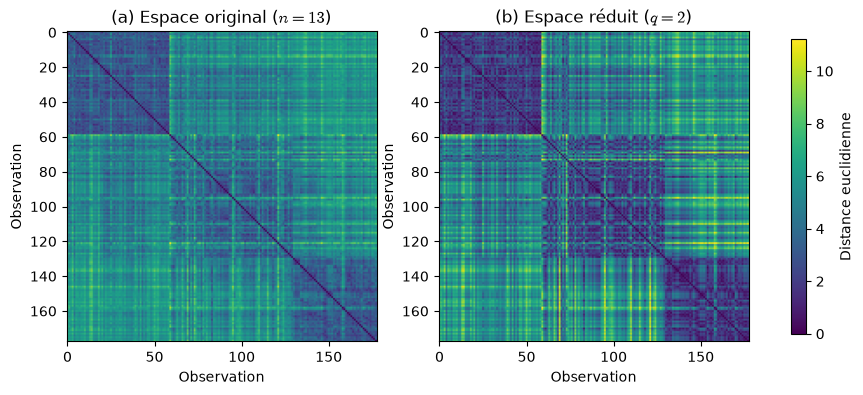

In [24]:
# Affichage côte à côte des matrices de dissimilarités
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

vmax = original_distances.max()
for ax, M, titre in [(axes[0], original_distances,
                      "(a) Espace original ($n = 13$)"),
                     (axes[1], reduced_distances,
                      "(b) Espace réduit ($q = 2$)")]:
    im = ax.imshow(M, cmap='viridis', vmin=0, vmax=vmax)
    ax.set_title(titre)
    ax.set_xlabel('Observation'); ax.set_ylabel('Observation')

fig.colorbar(im, ax=axes, shrink=0.85, label='Distance euclidienne')
plt.show()

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap3-MDS-Matrices")

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 3.15 : Évolution du stress normalisé en fonction du nombre de dimensions</h3>

In [25]:
# Distances originales (triangle supérieur, sans la diagonale)
idx_triu = np.triu_indices(len(X_scaled), k=1)
D_orig   = pairwise_distances(X_scaled)[idx_triu]

stress_normalise = []
for q in range(1, X_scaled.shape[1] + 1):
    mds_q = MDS(n_components=q, metric_mds=True, metric='euclidean',
                random_state=42, init='random', n_init=5)
    Z_q = mds_q.fit_transform(X_scaled)
    d_q = pairwise_distances(Z_q)[idx_triu]
    s   = np.sqrt(np.sum((D_orig - d_q)**2) / np.sum(d_q**2))
    stress_normalise.append(s)

# Décroissance relative delta(q)
delta = [(stress_normalise[i-1] - stress_normalise[i]) /
         stress_normalise[i-1]
         for i in range(1, len(stress_normalise))]

# Décroissance absolue Delta(q)
Delta_abs = [stress_normalise[i-1] - stress_normalise[i]
             for i in range(1, len(stress_normalise))]

# Affichage
print("=" * 40)
print("Stress normalisé (Kruskal) en fonction de q")
print("=" * 40)
print(f"{'q':<6}\t{'Stress':<10}\t{'δ(q)':<10}\t{'Δ(q)'}")
print("-" * 40)
print(f"{1:<6}\t{stress_normalise[0]:<10.4f}\t{'-':<10}\t-")
for i in range(len(delta)):
    q = i + 2
    print(f"{q:<6}\t{stress_normalise[q - 1]:<10.4f}\t{delta[i]:<10.4f}\t{Delta_abs[i]:.4f}")
print("=" * 40)

Stress normalisé (Kruskal) en fonction de q
q     	Stress    	δ(q)      	Δ(q)
----------------------------------------
1     	0.5025    	-         	-
2     	0.2353    	0.5317    	0.2672
3     	0.1497    	0.3638    	0.0856
4     	0.1012    	0.3237    	0.0485
5     	0.0718    	0.2904    	0.0294
6     	0.0526    	0.2680    	0.0193
7     	0.0383    	0.2720    	0.0143
8     	0.0291    	0.2400    	0.0092
9     	0.0223    	0.2330    	0.0068
10    	0.0175    	0.2165    	0.0048
11    	0.0127    	0.2728    	0.0048
12    	0.0116    	0.0870    	0.0011
13    	0.0095    	0.1796    	0.0021


<h3><span style="font-size: 30px">&#127924;</span> Figure : Évolution du stress normalisé et coude estimé (Kneedle)</h3>

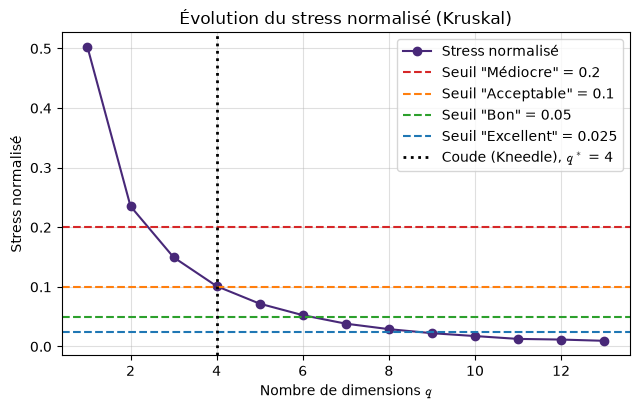

In [26]:
from kneed import KneeLocator

q_max = X_scaled.shape[1]
kl = KneeLocator(range(1, q_max + 1), stress_normalise, curve='convex', direction='decreasing')
q_star = kl.knee

# Stress normalisé + grille de Kruskal + coude
fig, ax = plt.subplots(figsize=(6.5, 4.2))

ax.plot(range(1, q_max + 1), stress_normalise, 'o-', color='#482878', label='Stress normalisé')
ax.axhline(0.2, color='#d62728', linestyle='--', label='Seuil "Médiocre" = 0.2')
ax.axhline(0.1, color='#ff7f0e', linestyle='--', label='Seuil "Acceptable" = 0.1')
ax.axhline(0.05, color='#2ca02c', linestyle='--', label='Seuil "Bon" = 0.05')
ax.axhline(0.025, color='#1f77b4', linestyle='--', label='Seuil "Excellent" = 0.025')
ax.axvline(q_star, color='black', linestyle=':', linewidth=2, label=f'Coude (Kneedle), $q^*$ = {q_star}')
ax.set_title('Évolution du stress normalisé (Kruskal)')
ax.set_xlabel('Nombre de dimensions $q$')
ax.set_ylabel('Stress normalisé')
ax.legend()
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap3-MDS-Stress-Coude")

<h3><span style="font-size: 30px">&#127924;</span> Figure : Décroissances relative et absolue du stress</h3>

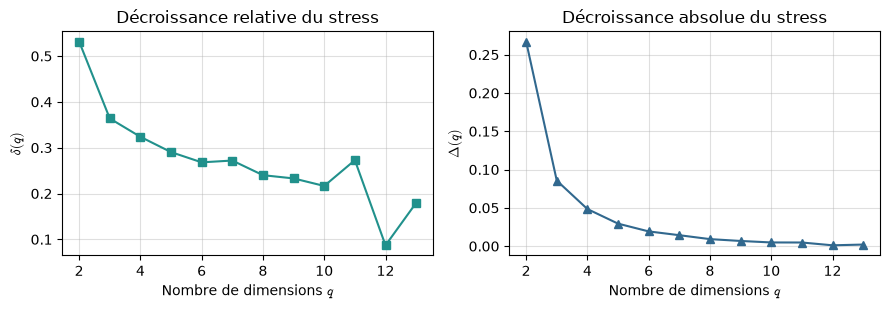

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2))

axes[0].plot(range(2, q_max + 1), delta, 's-', color='#21918c', label='$\\delta(q)$')
axes[0].set_title('Décroissance relative du stress')
axes[0].set_xlabel('Nombre de dimensions $q$')
axes[0].set_ylabel('$\\delta(q)$')

axes[1].plot(range(2, q_max + 1), Delta_abs, '^-', color='#31688e', label='$\\Delta(q)$')
axes[1].set_title('Décroissance absolue du stress')
axes[1].set_xlabel('Nombre de dimensions $q$')
axes[1].set_ylabel('$\\Delta(q)$')

for ax2 in axes:
    ax2.grid(alpha=0.4)

plt.tight_layout()
plt.show()

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap3-MDS-Deltas")

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 3.16 : Chargement du jeu de données Digits</h3>

In [28]:
from sklearn.datasets import load_digits

data = load_digits()
X, y = data.data, data.target

<h3><span style="font-size: 30px">&#127924;</span> Figure : Exemples d'images du jeu de données Digits</h3>

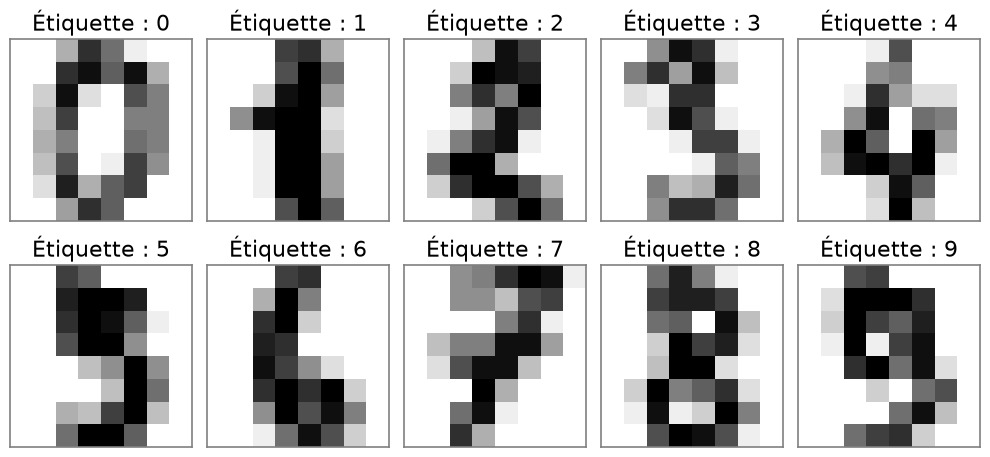

In [29]:
# Affichage d'un exemple de chaque chiffre (images 8 x 8)
fig, axes = plt.subplots(2, 5, figsize=(10, 4.6))

for ax, chiffre in zip(axes.ravel(), range(10)):
    idx = np.where(y == chiffre)[0][0]   # premier exemple du chiffre
    ax.imshow(data.images[idx], cmap='gray_r', vmin=0, vmax=16)
    ax.set_title(f"Étiquette : {chiffre}", fontsize=16)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor('gray')
        spine.set_linewidth(1.2)
plt.tight_layout()
fig.subplots_adjust(hspace=0.20)

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap3-Digits-Exemples")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 3.17 : Application de t-SNE sur le jeu de données Digits</h3>

In [30]:
from sklearn.manifold import TSNE

tsne   = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
Z_tsne = tsne.fit_transform(X)

print(f"KL divergence finale (perplexité=30) : {tsne.kl_divergence_:.4f}")

KL divergence finale (perplexité=30) : 0.7538


<h3><span style="font-size: 30px">&#127924;</span> Figure : Projection t-SNE du jeu de données Digits</h3>

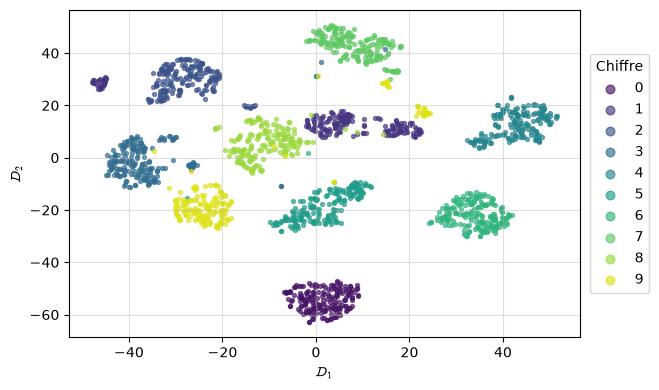

In [31]:
fig, ax = plt.subplots(figsize=(6, 4))

classes  = np.unique(y)
couleurs = plt.cm.viridis(np.linspace(0.05, 0.95, len(classes)))

for cls, couleur in zip(classes, couleurs):
    idx = (y == cls)
    ax.scatter(Z_tsne[idx, 0], Z_tsne[idx, 1], s=8, alpha=0.65,
               color=couleur, label=str(cls))

ax.set_xlabel('$D_1$')
ax.set_ylabel('$D_2$')
ax.grid(alpha=0.4)

plt.tight_layout()

ax.legend(title='Chiffre', loc='center left', bbox_to_anchor=(1.02, 0.5),
          markerscale=2.2, borderaxespad=0.)

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap3-TSNE-Projection")

plt.show()

<h3><span style="font-size: 30px">&#128187;</span> Extrait de code 3.18 : Effet de la perplexité sur la projection t-SNE</h3>

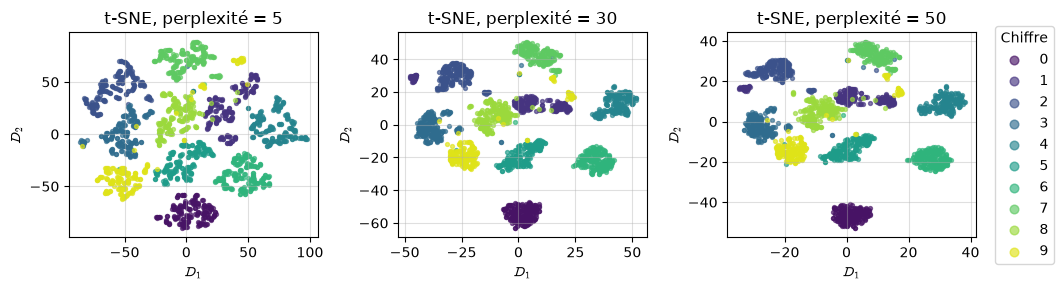

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3))

classes  = np.unique(y)
couleurs = plt.cm.viridis(np.linspace(0.05, 0.95, len(classes)))
for ax, perp in zip(axes, [5, 30, 50]):
    tsne_p = TSNE(n_components=2, perplexity=perp, random_state=42, max_iter=1000)
    Z = tsne_p.fit_transform(X)
    for cls, couleur in zip(classes, couleurs):
        idx = (y == cls)
        ax.scatter(Z[idx, 0], Z[idx, 1], s=8, alpha=0.65,
                   color=couleur, label=str(cls))
    ax.set_title(f"t-SNE, perplexité = {perp}")
    ax.set_xlabel('$D_1$'); ax.set_ylabel('$D_2$')
    ax.grid(alpha=0.4)

plt.tight_layout()

# Légende unique pour les trois panneaux
poignees, etiquettes = axes[0].get_legend_handles_labels()
fig.legend(poignees, etiquettes, title='Chiffre', loc='center left', bbox_to_anchor=(1.0, 0.5),
           markerscale=2.2, borderaxespad=0.)

# Sauvegarder la figure
save_figure(fig, "Figures/Fig-Chap3-TSNE-Perplexite")

plt.show()

<hr style='border-top:4px solid #1F77B4;'>